get twist evolution through time of the simulation. For one molecule.

In [27]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import cyltransf as ct
from scipy import odr

file_dir = "data100ns-2008"

universe = md.Universe(file_dir + "/md_1.tpr", file_dir + "/md_1_noPBC.xtc")
protein = universe.select_atoms("protein")
atom_group = protein.select_atoms("name CA") # Selection of specific type of atoms
chains = atom_group.fragments

In [28]:
def model_fn(p, x):
    # Coefficients p, x data
    m, c = p
    return m * x + c

In [29]:
mol_id = 0
molecule = chains[3 * mol_id: 3 * mol_id + 3]

psi = np.zeros(len(universe.trajectory))
i = 0

# For each frame
for ts in universe.trajectory:
    # Get coordinates and center
    com = protein.center_of_mass()
    molecule_coords = (molecule[0] + molecule[1]+ molecule[2]).positions - np.array([com[0], com[1], 0.0])

    # Cylindrical Projection
    molecule_coords_filt = ct.remove_ends(0.5, molecule_coords) / 10
    r, phi, z = ct.cyl_proj(molecule_coords_filt)
    arc = r*phi

    # Fit
    model = odr.Model(model_fn)
    data = odr.Data(z, arc)
    odr_run = odr.ODR(data, model, beta0=[0, np.mean(arc)]) # Guess Parameters (i think its irrelevant)
    res = odr_run.run()

    # Get psi
    psi[i] = np.rad2deg(np.atan(res.beta[0]))
    i += 1

Plot evolution

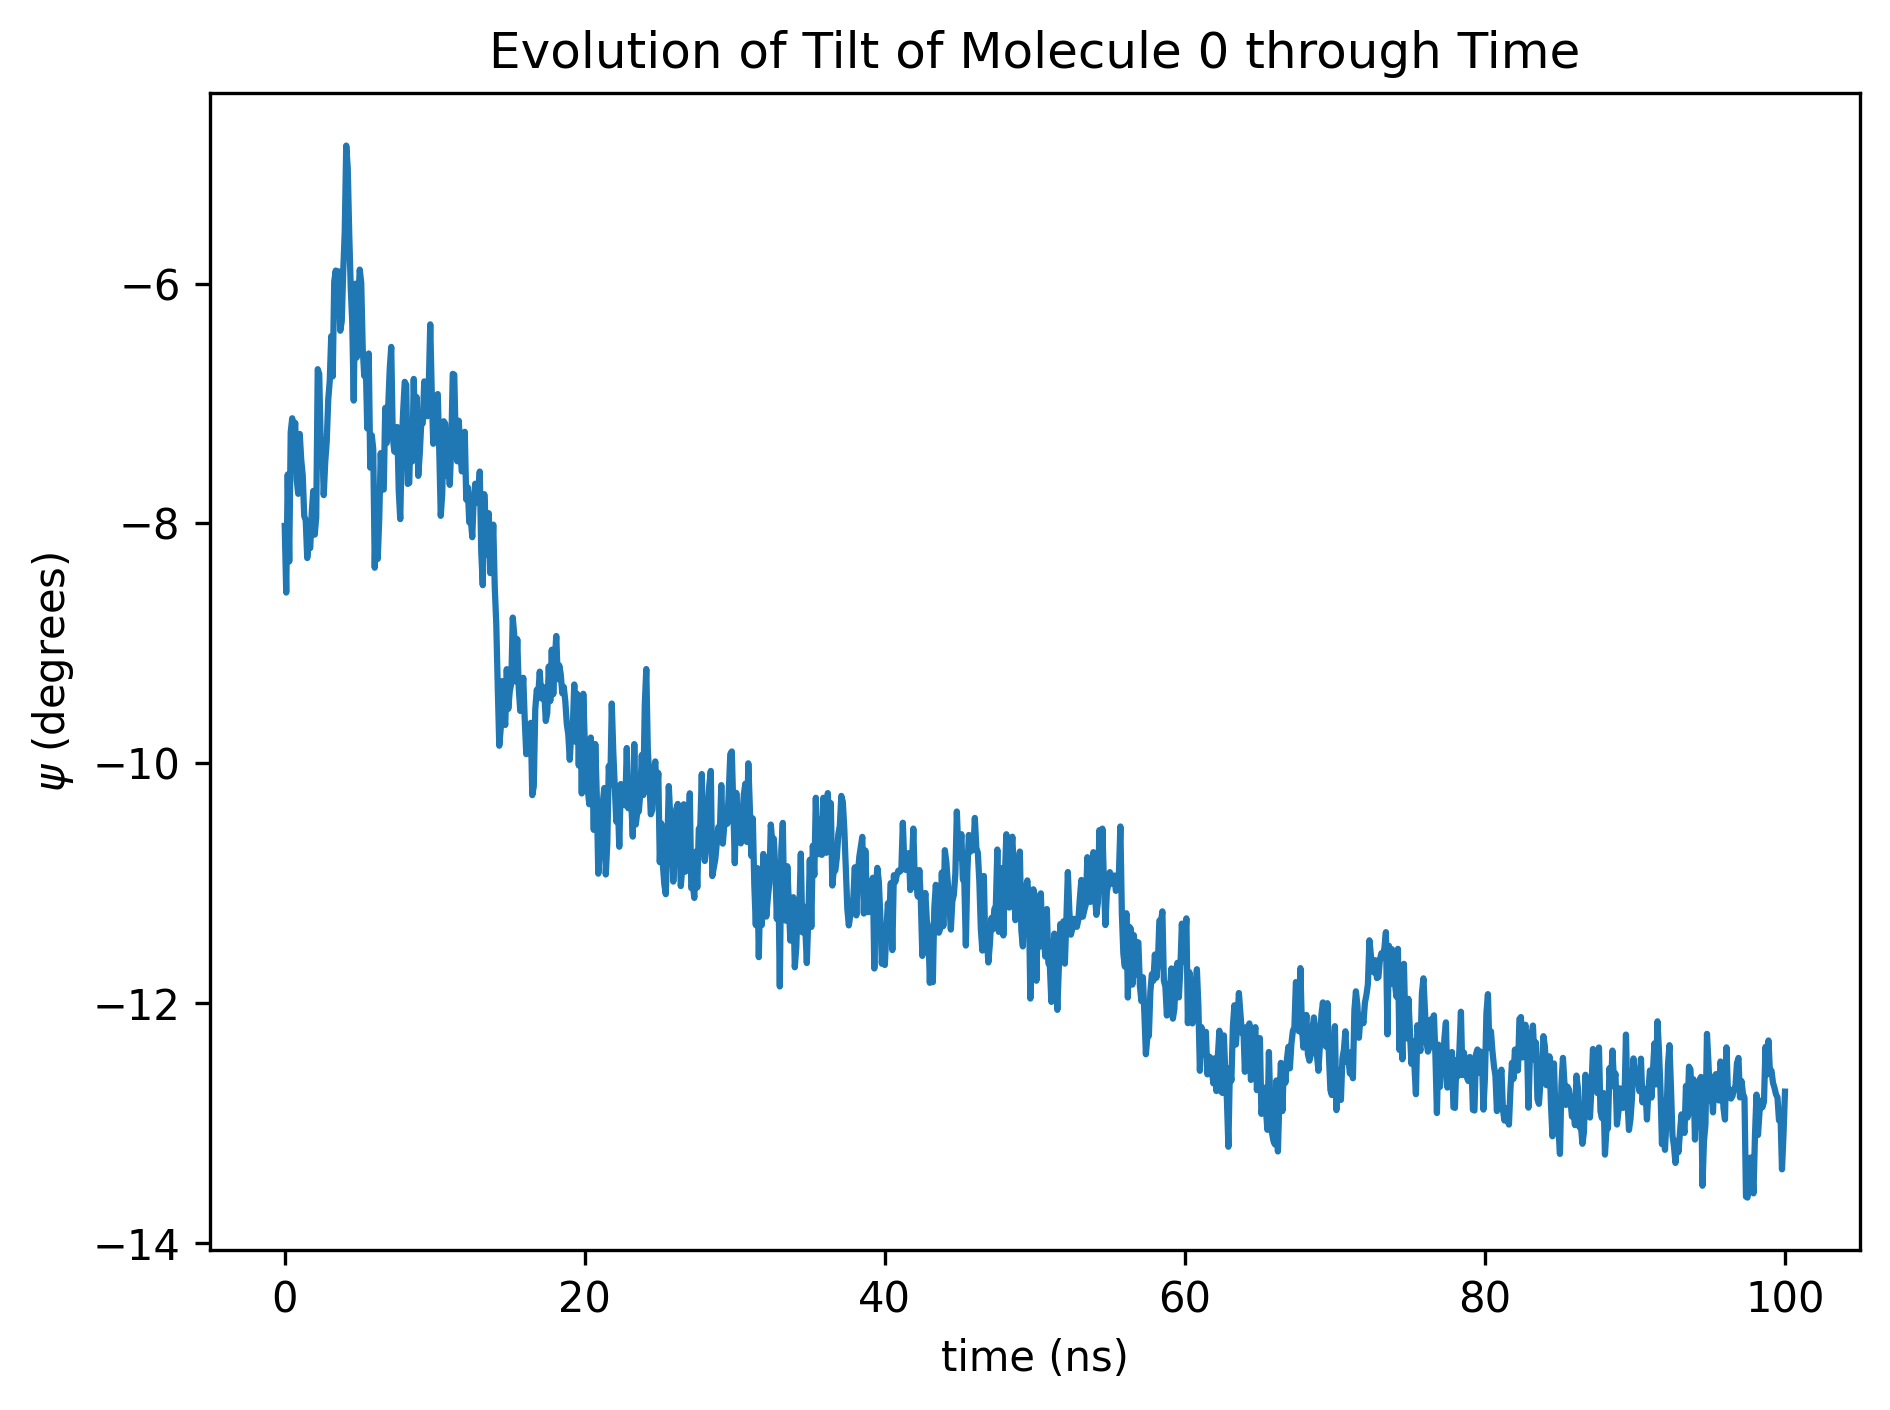

In [31]:
plt.figure(dpi=300)

t = np.linspace(0, 100, len(universe.trajectory))

plt.plot(t, psi)

plt.xlabel('time (ns)')
plt.ylabel(r'$\psi$ (degrees)')
plt.title(f'Evolution of Tilt of Molecule {mol_id} through Time')

plt.tight_layout()
plt.show()

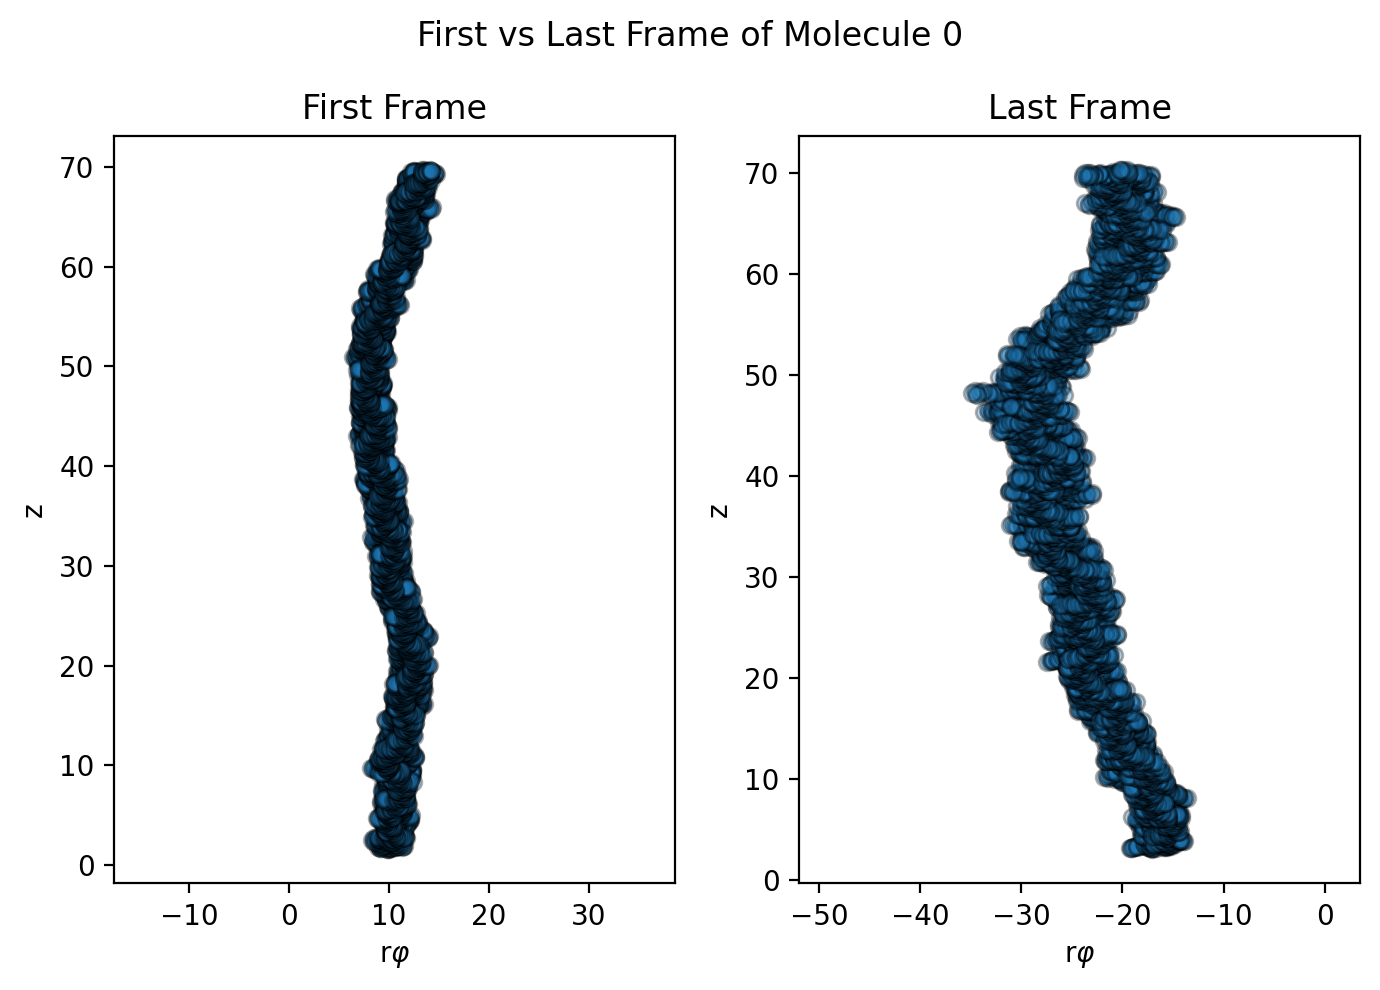

In [32]:
# Comparison first and last frame
fig, ax = plt.subplots(1, 2, figsize=(7,5), dpi=200)

# First frame
universe.trajectory[0]
com = protein.center_of_mass()
molecule_coords = (molecule[0] + molecule[1]+ molecule[2]).positions - np.array([com[0], com[1], 0.0])
# molecule_coords_filt = ct.remove_ends(0.5, molecule_coords) / 10
r, phi, z = ct.cyl_proj(molecule_coords / 10)
arc = r*phi

ax[0].scatter(arc, z, alpha=0.3, edgecolor='k')
ax[0].axis('equal')
ax[0].set_xlabel(r'r$\varphi$')
ax[0].set_ylabel(r'z')
ax[0].set_title('First Frame')

# First frame
universe.trajectory[-1]
com = protein.center_of_mass()
molecule_coords = (molecule[0] + molecule[1]+ molecule[2]).positions - np.array([com[0], com[1], 0.0])
# molecule_coords_filt = ct.remove_ends(0.5, molecule_coords) / 10
r, phi, z = ct.cyl_proj(molecule_coords / 10)
arc = r*phi

ax[1].scatter(arc, z, alpha=0.3, edgecolor='k')
ax[1].axis('equal')
ax[1].set_xlabel(r'r$\varphi$')
ax[1].set_ylabel(r'z')
ax[1].set_title('Last Frame')


plt.suptitle(rf'First vs Last Frame of Molecule {mol_id}')
plt.tight_layout()
plt.show()
